# HumBugDB Raw Audio Preprocessing
This notebook extracts 1D acoustic waveforms from the HumBugDB dataset, maps them to their respective species using the metadata CSV, and exports a PyTorch `TensorDataset` for training a SincNet architecture.

In [10]:
import os

# Create the target directory if it doesn't exist
os.makedirs('./data/audio/', exist_ok=True)

print("Extracting audio files. This may take a few minutes...")

# Unzip all downloaded HumBugDB zip files into the target folder quietly (-q)
!unzip -q "humbugdb_neurips_2021_*.zip" -d ./data/audio/

print("Extraction complete!")

Extracting audio files. This may take a few minutes...

4 archives were successfully processed.
Extraction complete!


In [4]:
print("Downloading HumBugDB metadata CSV from Zenodo...")

# Download the specific CSV file directly to your current working directory
!wget -O ./neurips_2021_zenodo_0_0_1.csv "https://zenodo.org/record/4904800/files/neurips_2021_zenodo_0_0_1.csv?download=1"

print("Metadata download complete!")

--2026-08-07 17:41:00--  https://zenodo.org/record/4904800/files/neurips_2021_zenodo_0_0_1.csv?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4904800/files/neurips_2021_zenodo_0_0_1.csv [following]
--2026-08-07 17:41:01--  https://zenodo.org/records/4904800/files/neurips_2021_zenodo_0_0_1.csv
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1533087 (1.5M) [text/plain]
Saving to: ‘./neurips_2021_zenodo_0_0_1.csv’

./neurips_2021_zeno 100%[===================>]   1.46M   504KB/s    in 3.0s    

2026-08-07 17:41:05 (504 KB/s) - ‘./neurips_2021_zenodo_0_0_1.csv’ saved [1533087/1533087]

Metadata download complete!


In [38]:
import os
import pandas as pd
import glob

# 1. Verify the metadata loads correctly
try:
    df = pd.read_csv('./neurips_2021_zenodo_0_0_1.csv')
    print(f"- Metadata successfully loaded! Found {len(df)} total records.")
except FileNotFoundError:
    print("- Error: Metadata CSV not found.")

# 2. Verify the audio files extracted correctly
audio_files = glob.glob('./data/audio/**/*.wav', recursive=True)
if len(audio_files) > 0:
    print(f"- Audio extraction verified! Found {len(audio_files)} .wav files in ./data/audio/")
else:
    print("- Error: No .wav files found in ./data/audio/. Check your unzip path.")

- Metadata successfully loaded! Found 9295 total records.
- Audio extraction verified! Found 9295 .wav files in ./data/audio/


In [39]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Metal GPU is active!")
else:
    device = torch.device("cpu")

Metal GPU is active!


In [40]:
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset
from tqdm import tqdm

## Configuration and Constants
Define the file paths and the audio parameters. Because we are using SincNet, we only need a 1D tensor representing the raw waveform instead of converting to a 2D Mel-spectrogram.

In [41]:
# The path to the audio files
DATA_DIR = "./data/audio/" 
METADATA_PATH = "./neurips_2021_zenodo_0_0_1.csv"
PROCESSED_DATA_PATH = "./processed_mosquito_dataset.pt"

# Audio parameters for SincNet (Raw Waveform)
SAMPLE_RATE = 8000
DURATION = 1.0  # 1-second chunks
TARGET_LENGTH = int(SAMPLE_RATE * DURATION)

## 1. Load and Filter Metadata
The dataset contains multiple species, such as 'an arabiensis', 'culex pipiens complex', 'ae aegypti', 'an funestus ss', 'an squamosus', 'an coustani', 'ma uniformis', and 'ma africanus'. We will filter for specific *Anopheles* and *Culex* classes and map them to numeric integers for PyTorch.

In [42]:
# Load the HumBugDB metadata
print("Loading metadata...")
df = pd.read_csv(METADATA_PATH)

target_species = [
    'culex pipiens complex', 
    'ae aegypti', 
    'an arabiensis', 
    'an funestus ss', 
    'an squamosus', 
    'an coustani'
]

# --- NEW: Binary Classification Mapping ---
# 0 = Non-Vector (Culex / Aedes)
# 1 = Malaria Vector (All Anopheles species)
species_map = {
    'culex pipiens complex': 0,
    'ae aegypti': 0,
    'an arabiensis': 1,
    'an funestus ss': 1,
    'an squamosus': 1,
    'an coustani': 1
}
print("Binary Species to ID Mapping:", species_map)

df_filtered = df[df['species'].isin(target_species)].copy()
print(f"Total audio files to process: {len(df_filtered)}")

Loading metadata...
Binary Species to ID Mapping: {'culex pipiens complex': 0, 'ae aegypti': 0, 'an arabiensis': 1, 'an funestus ss': 1, 'an squamosus': 1, 'an coustani': 1}
Total audio files to process: 3267


## 2. Define Audio Processing Logic
We load the `.wav` file, ensure the sample rate is 8000Hz, and pad or truncate the 1D array to exactly `TARGET_LENGTH` samples to guarantee uniform tensor dimensions.

In [43]:
def process_raw_audio(file_id, data_dir=DATA_DIR, sr=SAMPLE_RATE, target_length=TARGET_LENGTH):
    file_path = os.path.join(data_dir, f"{file_id}.wav")
    
    if not os.path.exists(file_path):
        return None
        
    try:
        y, _ = librosa.load(file_path, sr=sr)
        
        # --- NEW: Energy-Based Windowing ---
        if len(y) > target_length:
            # 1. Calculate the squared energy of the signal
            energy = np.power(y, 2)
            # 2. Create a rolling window sum to find the densest 1-second of sound
            window = np.ones(target_length)
            rolling_energy = np.convolve(energy, window, mode='valid')
            # 3. Find the exact starting index of the loudest 1-second chunk
            start_idx = np.argmax(rolling_energy)
            # 4. Slice the audio at that exact hotspot
            y = y[start_idx : start_idx + target_length]
        elif len(y) < target_length:
            # Pad short audio as normal
            y = np.pad(y, (0, target_length - len(y)))
        # -----------------------------------
        
        # Peak Normalization (applied AFTER finding the hotspot)
        max_amplitude = np.max(np.abs(y))
        if max_amplitude > 0:
            y = y / max_amplitude
            
        y = np.reshape(y, (1, target_length))
        return y
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

## 3. Extract Features and Generate TensorDataset
Iterate over the filtered metadata, apply the processing function, and compile the final PyTorch dataset. This step will take some time depending on your disk read speed.

In [44]:
tensors_list = []
labels_list = []

print("Processing audio files...")
# Using tqdm to show a progress bar
for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    file_id = row['id']
    species = row['species']
    
    processed_audio = process_raw_audio(file_id)
    
    if processed_audio is not None:
        tensors_list.append(processed_audio)
        labels_list.append(species_map[species])

# Convert Python lists to PyTorch tensors
X_tensor = torch.tensor(np.array(tensors_list), dtype=torch.float32)
y_tensor = torch.tensor(np.array(labels_list), dtype=torch.long)

print(f"\nFinal Features Tensor Shape: {X_tensor.shape}")
print(f"Final Labels Tensor Shape: {y_tensor.shape}")

# Package into a TensorDataset and save locally
dataset = TensorDataset(X_tensor, y_tensor)

# Checking class distribution
print("\n--- Final Processed Class Distribution ---")
unique_classes, class_counts = np.unique(labels_list, return_counts=True)

for cls, count in zip(unique_classes, class_counts):
    class_name = "Malaria Vector" if cls == 1 else "Non-Vector"
    print(f"{class_name} (Class {cls}): {count} files")

torch.save(dataset, PROCESSED_DATA_PATH)
print(f"Dataset successfully saved to {PROCESSED_DATA_PATH}")

Processing audio files...


100%|██████████| 3267/3267 [11:43<00:00,  4.65it/s]



Final Features Tensor Shape: torch.Size([3267, 1, 8000])
Final Labels Tensor Shape: torch.Size([3267])

--- Final Processed Class Distribution ---
Non-Vector (Class 0): 668 files
Malaria Vector (Class 1): 2599 files
Dataset successfully saved to ./processed_mosquito_dataset.pt


## 4. Verification and Visualization
Visualize a random processed sample to ensure the 1D waveform was captured correctly.

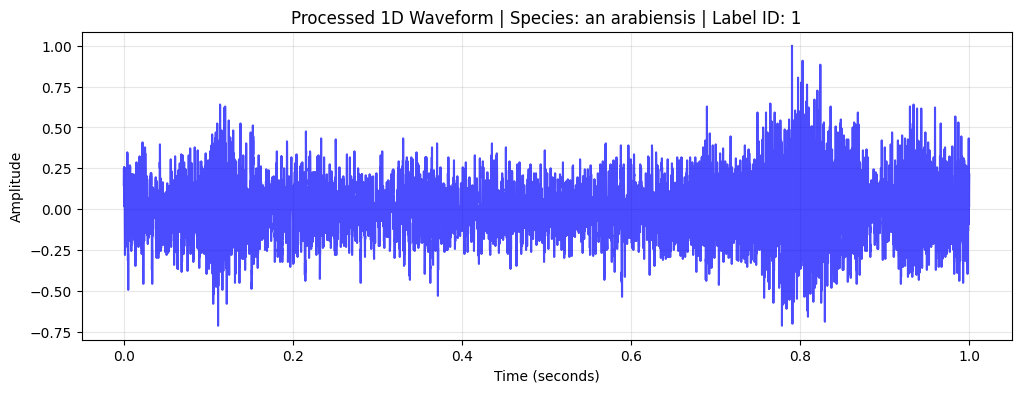

In [66]:
# Fetch a random sample from the generated tensors
sample_idx = np.random.randint(0, len(X_tensor))
sample_waveform = X_tensor[sample_idx].numpy().squeeze()
sample_label = list(species_map.keys())[list(species_map.values()).index(y_tensor[sample_idx].item())]

# Plot the 1D acoustic array
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, DURATION, len(sample_waveform)), sample_waveform, color='blue', alpha=0.7)
plt.title(f"Processed 1D Waveform | Species: {sample_label} | Label ID: {y_tensor[sample_idx].item()}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()